## Task 2: Sentiment Analysis using NLP Pipeline & ML Model

####  1: Data Understanding

In [1]:
!pip install nltk scikit-learn matplotlib

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
df = pd.read_csv("IMDB Dataset.csv", engine="python", on_bad_lines="skip")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
print("Total Samples:", len(df))
print(df['sentiment'].value_counts())

Total Samples: 50000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
print(df['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

####  2: NLP Preprocessing

In [6]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\jitendra
[nltk_data]     khandelwal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\jitendra
[nltk_data]     khandelwal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [8]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [9]:
df['clean_text'] = df['review'].apply(preprocess_text)

In [10]:
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

####  3: Feature Engineering

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

####  4: Model Building

In [15]:
from sklearn.linear_model import LogisticRegression

# TF-IDF
lr_tfidf = LogisticRegression(max_iter=500)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# BoW
lr_bow = LogisticRegression(max_iter=500)
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

In [16]:
from sklearn.naive_bayes import MultinomialNB

# TF-IDF
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# BoW
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

In [17]:
from sklearn.tree import DecisionTreeClassifier

# TF-IDF
dt_tfidf = DecisionTreeClassifier()
dt_tfidf.fit(X_train_tfidf, y_train)
y_pred_dt_tfidf = dt_tfidf.predict(X_test_tfidf)

# BoW
dt_bow = DecisionTreeClassifier()
dt_bow.fit(X_train_bow, y_train)
y_pred_dt_bow = dt_bow.predict(X_test_bow)

#### 5: Evaluation

In [18]:
def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

In [19]:
results_df = pd.DataFrame({
    "Model": [
        "LR TF-IDF", "LR BoW",
        "NB TF-IDF", "NB BoW",
        "DT TF-IDF", "DT BoW"
    ],
    "Accuracy": [
        evaluate(y_test, y_pred_lr_tfidf)[0],
        evaluate(y_test, y_pred_lr_bow)[0],
        evaluate(y_test, y_pred_nb_tfidf)[0],
        evaluate(y_test, y_pred_nb_bow)[0],
        evaluate(y_test, y_pred_dt_tfidf)[0],
        evaluate(y_test, y_pred_dt_bow)[0]
    ],
    "Precision": [
        evaluate(y_test, y_pred_lr_tfidf)[1],
        evaluate(y_test, y_pred_lr_bow)[1],
        evaluate(y_test, y_pred_nb_tfidf)[1],
        evaluate(y_test, y_pred_nb_bow)[1],
        evaluate(y_test, y_pred_dt_tfidf)[1],
        evaluate(y_test, y_pred_dt_bow)[1]
    ],
    "Recall": [
        evaluate(y_test, y_pred_lr_tfidf)[2],
        evaluate(y_test, y_pred_lr_bow)[2],
        evaluate(y_test, y_pred_nb_tfidf)[2],
        evaluate(y_test, y_pred_nb_bow)[2],
        evaluate(y_test, y_pred_dt_tfidf)[2],
        evaluate(y_test, y_pred_dt_bow)[2]
    ],
    "F1 Score": [
        evaluate(y_test, y_pred_lr_tfidf)[3],
        evaluate(y_test, y_pred_lr_bow)[3],
        evaluate(y_test, y_pred_nb_tfidf)[3],
        evaluate(y_test, y_pred_nb_bow)[3],
        evaluate(y_test, y_pred_dt_tfidf)[3],
        evaluate(y_test, y_pred_dt_bow)[3]
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,LR TF-IDF,0.8888,0.878981,0.903751,0.891194
1,LR BoW,0.8727,0.870523,0.877952,0.874222
2,NB TF-IDF,0.8546,0.851677,0.861480,0.856551
3,NB BoW,0.8514,0.856226,0.847390,0.851785
4,DT TF-IDF,0.7151,0.722290,0.706092,0.714099
5,DT BoW,0.7162,0.719179,0.716610,0.717893


#### 6. Comparison & Insights

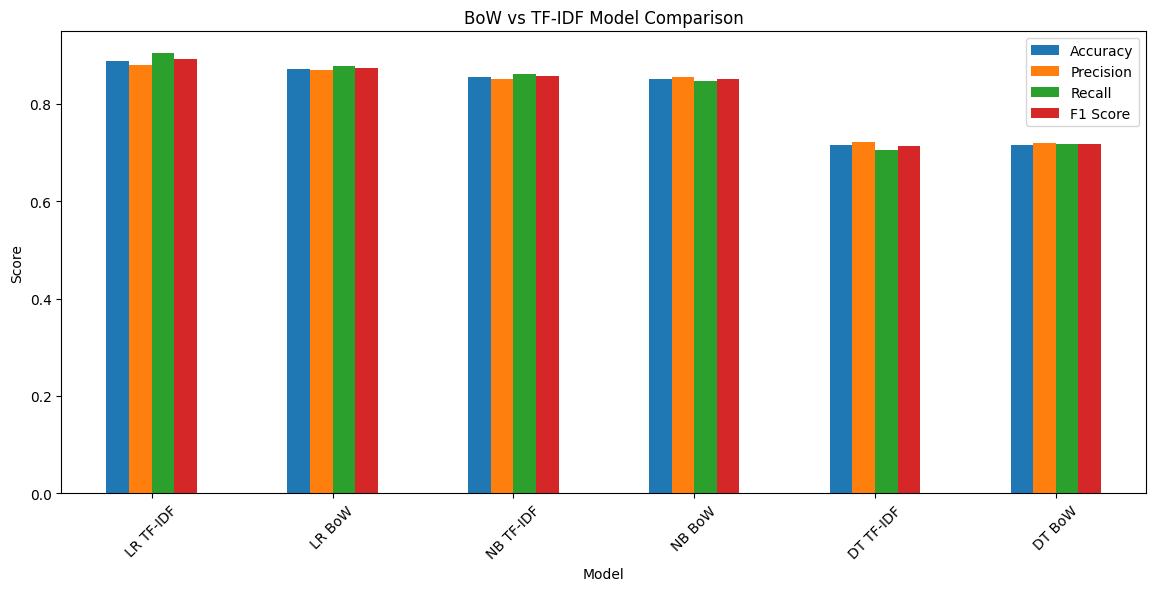

In [20]:
results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(14, 6)
)

plt.title("BoW vs TF-IDF Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [21]:
sample_reviews = [
    "I really loved this product, it was amazing!",
    "Worst experience ever, I hate it.",
    "This is okay, not too bad."
]

sample_clean = [preprocess_text(text) for text in sample_reviews]
sample_vector = tfidf_vectorizer.transform(sample_clean)

predictions = lr_tfidf.predict(sample_vector)

reverse_label_mapping = {0: "negative", 1: "positive"}

for review, pred in zip(sample_reviews, predictions):
    print("Review:", review)
    print("Predicted Sentiment:", reverse_label_mapping[pred])
    print("-" * 60)

Review: I really loved this product, it was amazing!
Predicted Sentiment: positive
------------------------------------------------------------
Review: Worst experience ever, I hate it.
Predicted Sentiment: negative
------------------------------------------------------------
Review: This is okay, not too bad.
Predicted Sentiment: negative
------------------------------------------------------------


### Insights

- TF-IDF based models performed better than Bag of Words (BoW) in most cases.
- Logistic Regression with TF-IDF achieved the highest accuracy among all models.
- Naive Bayes worked efficiently with both BoW and TF-IDF but gave slightly lower performance than Logistic Regression.
- Decision Tree showed lower performance and signs of overfitting, especially with BoW features.

### Best Model:
Logistic Regression with TF-IDF

### Feature Comparison:
- TF-IDF captures word importance better than BoW, leading to improved performance.
- BoW is simpler and faster but lacks contextual weighting of words.

### Trade-offs:
- TF-IDF → Better accuracy but slightly more computation
- BoW → Faster but less informative
- Logistic Regression → Best balance of performance and simplicity